<a href="https://colab.research.google.com/github/kzdanowski/KGN_Programowanie2/blob/main/Lab/P2Lab10_housing_essential_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data loading and exploration

In [3]:
wget https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv


SyntaxError: invalid syntax (4098623893.py, line 1)

In [6]:
import pandas as pd
import numpy as np

def load_housing_data(housing_path="/Users/weronikalewandowska/Desktop/repo_prog2/KGN_Programowanie2/content:housing.csv"):
  return pd.read_csv(housing_path)

housing = load_housing_data()

In [7]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [8]:
# 1. zobacz jakie wartości i ich ilość przyjmuje kolumna [ocean_proximity]
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


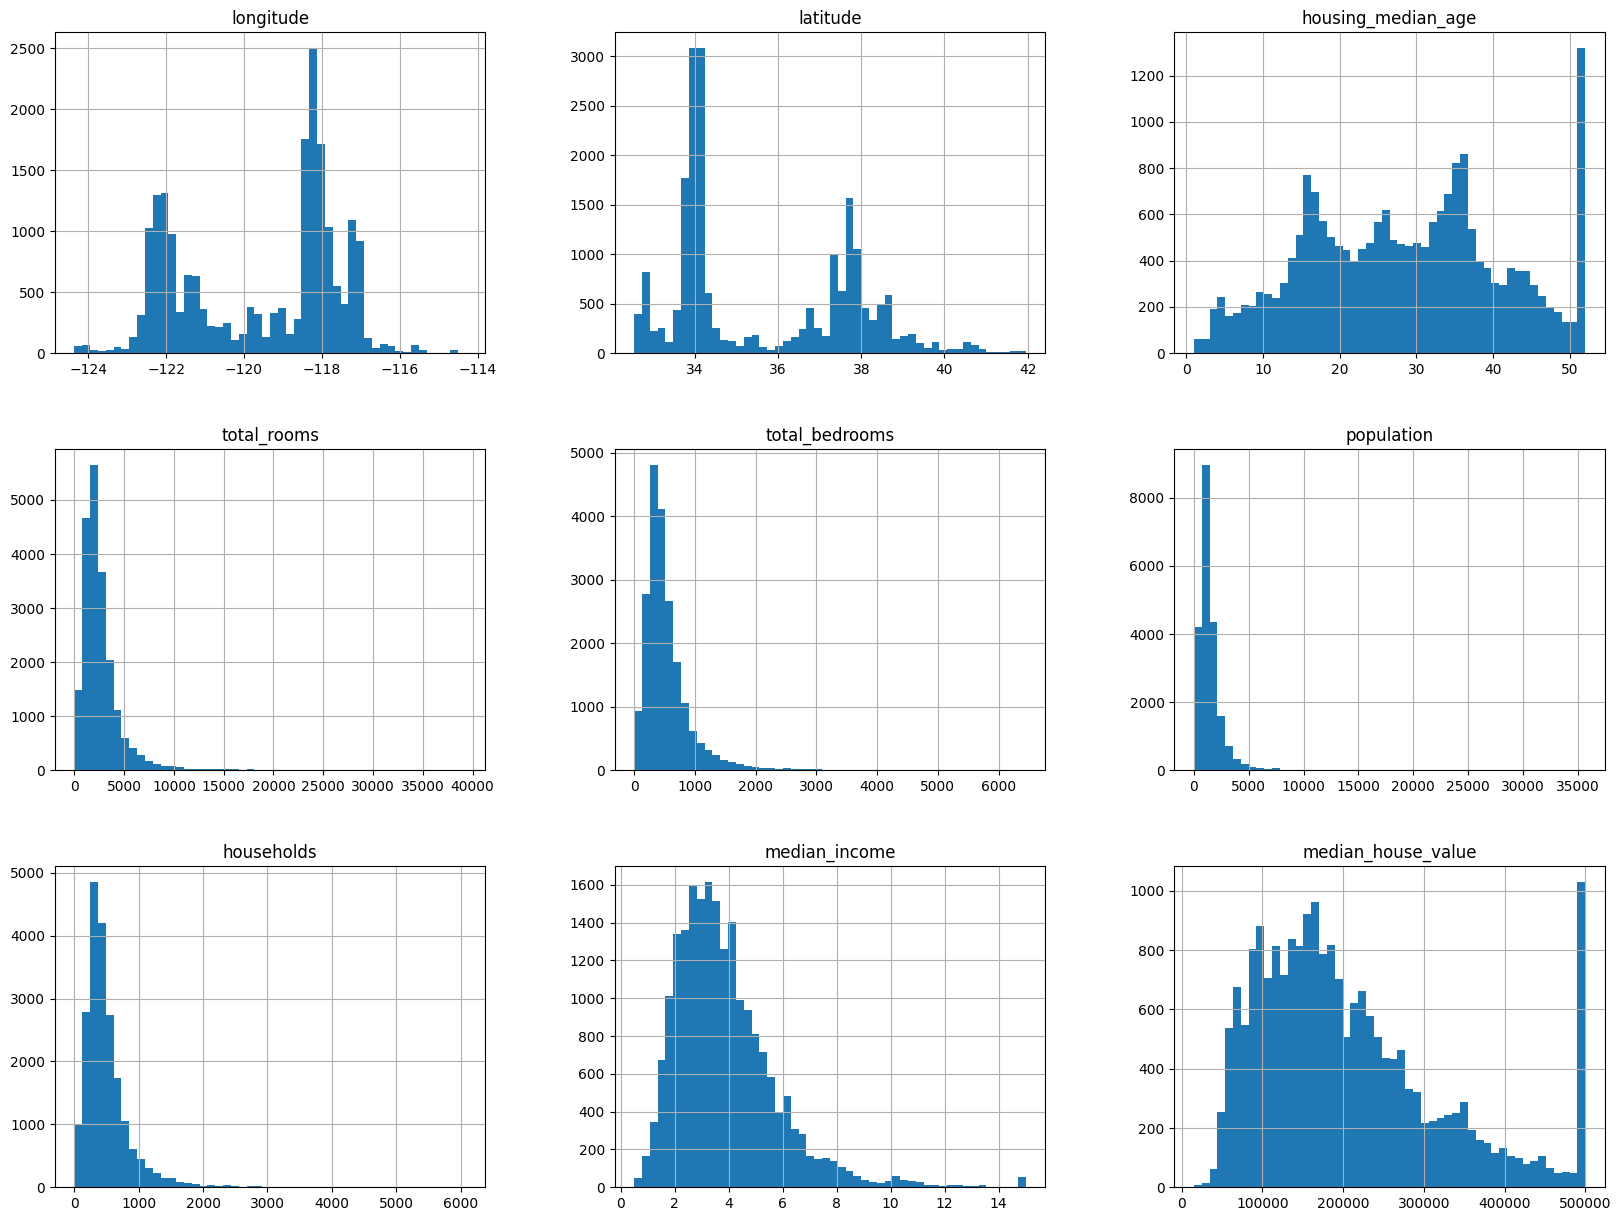

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

## Train - test split

In [11]:
from sklearn.model_selection import train_test_split
# train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

- Data stratification
- The	following	code	creates	an	income
 category	attribute	by	dividing	the	median	income	by	1.5	(to	limit	the	number	of	income	categories),	and
 rounding	up	using	ceil	(to	have	discrete	categories),	and	then	merging	all	the	categories	greater	than	5
 into	category	5

In [12]:
housing["income_cat"] = np.ceil(housing["median_income"] / 1.5)

In [13]:
housing["income_cat"] = housing["income_cat"].clip(upper=5)

In [14]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
  #pierwsze split to nazwa podzialu (powyzej) a drugie split to funkcja biblioteki ktora
  #dzieli dane i generuje indeksy- jako pierwszy arg caly zbior housing a jako drugi kolumne
  #wg ktorej ma zachowac proporcje czyli infome
  strat_train_set = housing.loc[train_index]
  #za pomoca loc wybiera z oryginalnego DataFrame (housing) wiersze, ktorych indekse znajduja
  #sie w train_index
  strat_test_set = housing.loc[test_index]

In [15]:
housing["income_cat"].value_counts() / len(housing)
#obliczanie proporcji kazdej z kategorii dochodow w calym zbiorze danych
#len zwraca calkowita ilosc wierszy, a dzielac zmieniamy liczby na ulamki (proporcje)

income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

In [16]:
# temporarly removing categorical data
for	set	in	(strat_train_set,	strat_test_set):
				set.drop(["income_cat"],	axis=1,	inplace=True)
#usuwamy kolumne income_cat bo spelnila swoje zadanie (stworzylismy aby stratifiedshuffle 
#podzielil dane w odpowiednich proporcjach. Mamy zbiory wiec kolumna nie jest potrzebna
#inplace = True czyli nadpisuje go bez potrzeby tworzenia nowej zmiennej)

In [17]:
housing = strat_train_set.copy()
#kopiujemy bo zbior testowy jest swiety i nie wolno nam na niego patrzec analizowac ani wizualizowac

## Visualisations and correlations

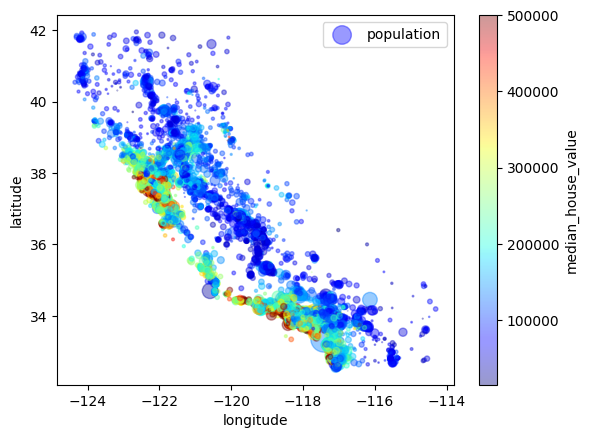

In [18]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
#scatter- kazdy punkt kropka
#dlugosc geograficzna; szerokosc- przypisuje kolumny do X i Y
#alpha- przezroczystosc kropek (od 0 do 1)
s=housing["population"]/100, label="population",
#s (size) to rozmiar (promien) kazdej kropki, dzielenie przez 100 zapobiega zeby nie byly za duze
c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,)
#c to kolory- kazdy kolor bedzie zalezec od mediany ceny domu
#cmap wybiera palete kolorow o nazwie jet (skala teczowa)
#colorbar wyswietla po prawej kolory

plt.show()

In [ ]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
housing[attributes].corr()
#correlation – korelacja) oblicza współczynnik korelacji liniowej Pearsona pomiędzy wybranymi kolumnami

,median_house_value,median_income,total_rooms,housing_median_age
median_house_value,1.000000,0.687151,0.135140,0.114146
median_income,0.687151,1.000000,0.200133,-0.111315
total_rooms,0.135140,0.200133,1.000000,-0.364535
housing_median_age,0.114146,-0.111315,-0.364535,1.000000


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

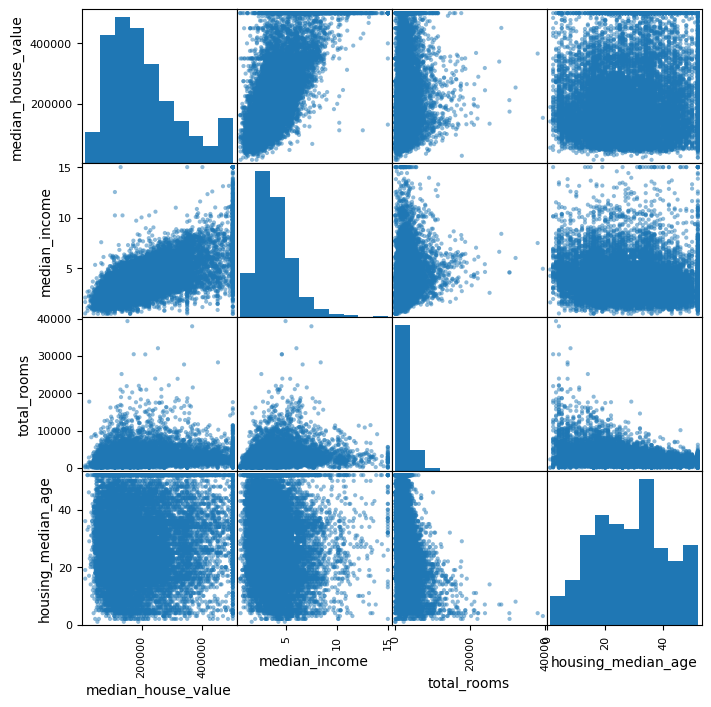

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(8, 8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

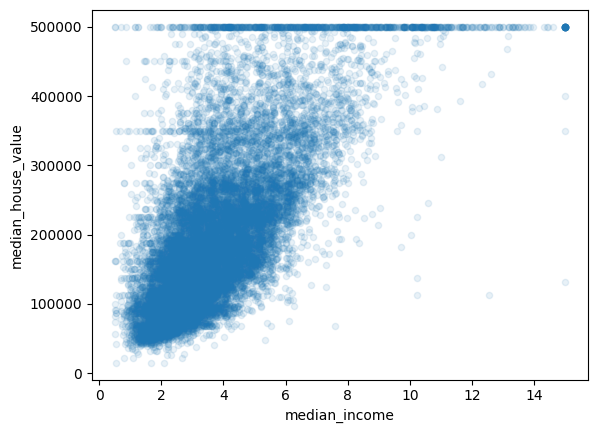

In [ ]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

Additional columns

In [ ]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
#inzynieria cech (feature engineering)- tworzy bardziej wartosciowe cechy na podstawie
#tych, ktore mamy w tabeli
housing["rooms_per_household"] = housing['total_rooms'] / housing['households']
housing["bedrooms_per_room"] = housing['total_bedrooms'] / housing['total_rooms']
housing["population_per_household"]= housing['population'] / housing['households']

In [ ]:
# wyrzuć kolumnę "ocean_proximity" z housing
housing_num = housing.drop("ocean_proximity", axis=1)

In [ ]:
# correlation with additional columns and without ocean proximity
corr_mat = housing_num.corr()
corr_mat["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.687151
rooms_per_household,0.146255
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047781
population_per_household,-0.021991
population,-0.026882
longitude,-0.047466


Label set separation!

In [ ]:
# oddziel zbiór danych przewidujących od zbioru danych do przewdzenia
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

# Data cleaning - pipeline

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, household_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
  def __init__(self, add_bedrooms_per_room = True):
    self.add_bedrooms_per_room = add_bedrooms_per_room
  def fit(self, X, y=None):
    return self
  def transform(self, X, y=None):
    rooms_per_household = X[:, rooms_ix] / X[:, household_ix]
    population_per_household = X[:, population_ix] / X[:, household_ix]
    if self.add_bedrooms_per_room:
      bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
      return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
    else:
      return np.c_[X, rooms_per_household, population_per_household]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
cat_attribs = ["ocean_proximity"]

num_pipeline = Pipeline([
  ('imputer', SimpleImputer(strategy="median")),
  ('attribs_adder', CombinedAttributesAdder()),
  ('std_scaler', StandardScaler()),
])
cat_pipeline = Pipeline([
  ('one_hot', OneHotEncoder()),
])

In [ ]:
full_pipeline = ColumnTransformer([
  ("num_pipeline", num_pipeline, num_attribs),
  ("cat_pipeline", cat_pipeline, cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
housing_prepared.shape

(16512, 16)

In [ ]:
pd.DataFrame(housing_prepared)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.017395,0.006223,-0.121122,0.0,1.0,0.0,0.0,0.0
1,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.569256,-0.040811,-0.810867,0.0,0.0,0.0,0.0,1.0
2,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,-0.018024,-0.075371,-0.338273,0.0,1.0,0.0,0.0,0.0
3,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,-0.595140,-0.106803,0.961205,0.0,0.0,0.0,0.0,1.0
4,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,0.251241,0.006109,-0.474513,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16507,1.251711,-1.220505,-1.165333,1.890456,1.696862,0.543471,1.341519,0.637374,0.466353,-0.092580,-0.443846,1.0,0.0,0.0,0.0,0.0
16508,-0.921368,1.342761,-1.085806,2.468471,2.161816,3.002174,2.451492,-0.557509,0.050362,0.023024,-0.516065,0.0,1.0,0.0,0.0,0.0
16509,-1.570794,1.310018,1.538566,-0.895802,-0.895679,-0.862013,-0.865118,-0.365475,-0.509240,-0.037436,0.322869,1.0,0.0,0.0,0.0,0.0
16510,-1.560803,1.249211,-1.165333,0.249005,0.112126,-0.189747,0.010616,0.168261,0.328149,-0.059156,-0.457023,1.0,0.0,0.0,0.0,0.0


# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(68627.87390018745)

In [ ]:
def display_scores(scores):
 print("Scores:", scores)
 print("Mean:", scores.mean())
 print("Standard deviation:", scores.std())

In [ ]:
from sklearn.model_selection import cross_val_score

lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Standard deviation: 2880.3282098180694


# Decision Tree Regressor Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# tree_reg = DecisionTreeRegressor()
# tree_reg.fit(housing_prepared, housing_labels)

In [ ]:
# from sklearn.metrics import mean_squared_error
# housing_predictions = tree_reg.predict(housing_prepared)
# lin_mse = mean_squared_error(housing_labels, housing_predictions)
# lin_rmse = np.sqrt(lin_mse)
# lin_rmse

In [ ]:
# from sklearn.model_selection import cross_val_score

# lin_scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
# lin_rmse_scores = np.sqrt(-lin_scores)
# display_scores(lin_rmse_scores)


# Random Forest Regressor Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:
# forest_reg = RandomForestRegressor()
# forest_reg.fit(housing_prepared, housing_labels)

# housing_predictions = forest_reg.predict(housing_prepared)
# forest_mse = mean_squared_error(housing_labels, housing_predictions)
# forest_rmse = np.sqrt(forest_mse)

# forest_rmse

In [ ]:
# from sklearn.model_selection import cross_val_score
# scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
# scoring="neg_mean_squared_error", cv=10)
# forest_rmse_scores = np.sqrt(-scores)

In [ ]:
# display_scores(forest_rmse_scores)

In [ ]:
# mean_cost = housing_labels.mean()
# mean_cost

# Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [3, 10, 30], 'max_features': [2, 4, 6, 8]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training
grid_search = GridSearchCV(forest_reg, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [ ]:
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30, random_state=42)

# Ocena na zbiorze testowym

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

In [ ]:
X_test_prepared = full_pipeline.transform(X_test)

In [ ]:
test_pred = best_model.predict(X_test_prepared)

In [ ]:
test_estim = mean_squared_error(y_test, test_pred)

In [ ]:
final_rmse = np.sqrt(test_estim)
final_rmse

np.float64(47873.26095812988)

# Randomized search

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Define the model to be tuned
forest_reg = RandomForestRegressor(random_state=42)

# Create a pipeline that combines preprocessing and the model
final_pipeline = Pipeline([
# Naming the full_pipeline step 'preprocessor'
    ('regressor', forest_reg)        # Naming the RandomForestRegressor step 'regressor'
])

# Adjust parameter distributions to target the named steps in final_pipeline
param_distribs = {
    # Removed 'preprocessing__geo__n_clusters' as there's no 'geo' step in full_pipeline.
    # If a clustering step like KMeans were added to num_pipeline, it would be 'preprocessor__num_pipeline__kmeans__n_clusters'
    'regressor__n_estimators': randint(low = 3, high=200),
    'regressor__max_features': randint(low=2, high=20)
}

rnd_search = RandomizedSearchCV(
    final_pipeline, param_distributions=param_distribs, n_iter=10, cv=3,
    scoring='neg_root_mean_squared_error', random_state=42)

rnd_search.fit(housing_prepared, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'regressor__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c27fa2aa870>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c27fa2aa4b0>},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [ ]:
rnd_search.best_params_

{'regressor__max_features': 8, 'regressor__n_estimators': 31}